In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from scipy.signal import find_peaks, peak_widths
from scipy.ndimage import gaussian_filter1d  # For smoothing

from numba import jit, njit
from scipy.ndimage import gaussian_filter


In [18]:
arr_UB = []
arrG0 = []
arrGIMG = []
arr_en = []
arrGam = []
shift_0 = []
shift_IMG = []




NG_tot = 5
for nIMG in range(-1,NG_tot):
    
    #Function to re-import the data and parameters from target file
    # Read the parameters
    params_sys = {}
    with open('G_%d.dat' % (nIMG), 'r') as f:
        for line in f:
            if line.startswith("#"):
                key, value = line[1:].strip().split(" = ")
                params_sys[key] = float(value) if '.' in value or 'e' in value.lower() else int(value)
            else:
                break

    t, W, L, xic, plate_distance, E_dis, E_img, omB, iter_dis, Ncore = params_sys.values()
    alpha = omB/(4*np.pi)
    lB = 1./np.sqrt(2*np.pi*alpha)

    arr_UB.append( E_img/(omB*lB*1.25) )    #here we take as a reference e^2/(8\pi\epsilon) = 0.055 meV \mu m ... considering B=1T, omB=1.76 meV, l_B=25 nm, E_img = 1.25*omB*lB = 0.055

    # Read the data
    data = pd.read_csv('G_%d.dat' % (nIMG), sep=' ', comment='#')

    energies = data['arrE'].to_numpy()
    G0 = data['G0'].to_numpy()
    GIMG = data['GIMG'].to_numpy()
    
    ns = 0
    nf = len(energies)-1
    
    G0 = G0[ns:nf]
    GIMG = GIMG[ns:nf]
    energies = energies[ns:nf]
    
    
    arrG0.append( G0 )
    arrGIMG.append( GIMG )
    arr_en.append(energies)


arrG0 = np.asarray(arrG0)
arrGIMG = np.asarray(arrGIMG)
arr_en = np.asarray(arr_en)
distance = 13./np.asarray( arr_UB )

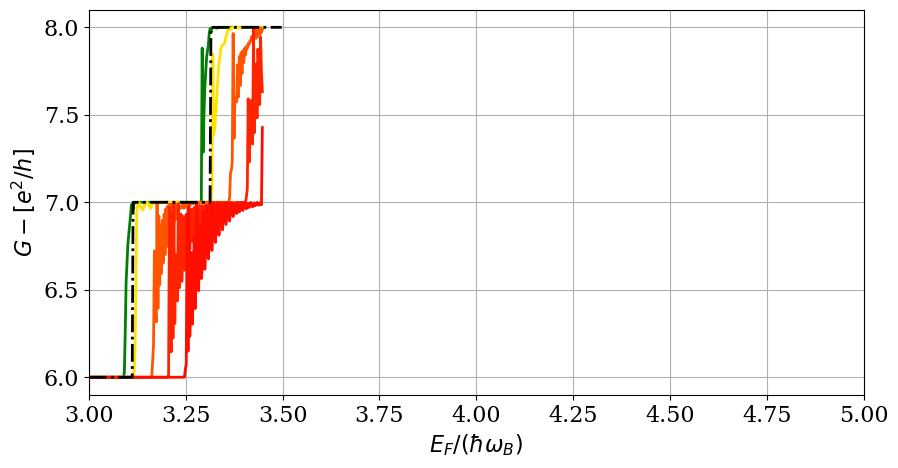

In [19]:
from matplotlib.colors import Normalize
import matplotlib.colors as mcolors


# Second plot (blue curve, right y-axis)
norm = Normalize(vmin=min(distance), vmax=max(distance))  # Normalize gS values
#cmap = plt.get_cmap('coolwarm')  # Color map transitioning from blue to red
cmap = mcolors.LinearSegmentedColormap.from_list("red_to_grey", ["red", "yellow", "green"])

# Font configuration
font = {
    'family': 'serif',
    'color': 'black',
    'weight': 'normal',
    'size': 16,
}
# Apply the font globally
plt.rcParams['font.family'] = font['family']
plt.rcParams['font.size'] = font['size']
plt.rcParams['axes.labelsize'] = font['size']
plt.rcParams['xtick.labelsize'] = font['size']
plt.rcParams['ytick.labelsize'] = font['size']

# Create the figure and subplots
fig, ax1 = plt.subplots(1, 1, figsize=(10, 5))
shiftE = -.05
for nG in range(NG_tot):
    color = cmap(norm(distance[nG]))
    ax1.plot( (arr_en[nG] ) / omB + shiftE, arrGIMG[nG], color=color, linewidth=2, label='|GIMGT - 2|')

ax1.plot( (arr_en[0] ) / omB, arrG0[0], color='black', linewidth=2, linestyle='-.')


ax1.set_ylabel(r"$G - [e^2/h]$", fontdict=font)
ax1.set_xlabel(r"$E_F/(\hbar\omega_B)$", fontdict=font)

ax1.set_xlim(3.,5)


ax1.grid()


5 -0.23100041376634975 (1.0, 0.0, 0.0, 1.0)
4 -0.18105416541446356 (1.0, 0.054901960784313725, 0.0, 1.0)
3 -0.13542822291671136 (1.0, 0.1411764705882353, 0.0, 1.0)
2 -0.0946947576044259 (1.0, 0.32941176470588235, 0.0, 1.0)
1 -0.05971328821614066 (1.0, 0.8862745098039215, 0.0, 1.0)
0 -0.032 (0.0, 0.5019607843137255, 0.0, 1.0)


/var/folders/y4/dpq6l9fj2kv9z0prq_6_pyy00000gn/T/ipykernel_59649/1051918345.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


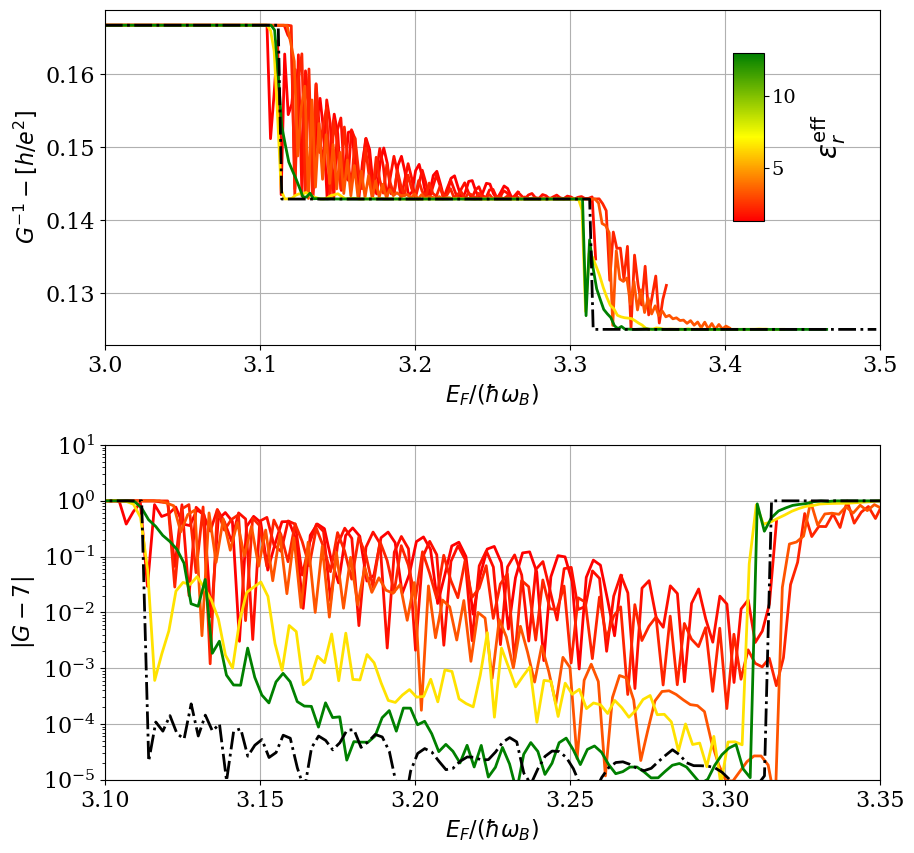

In [21]:
from matplotlib.colors import Normalize
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


# Normalization and colormap
norm = Normalize(vmin=min(distance), vmax=max(distance))
cmap = mcolors.LinearSegmentedColormap.from_list("red_to_grey", ["red", "yellow", "green"])
#cmap = mcolors.LinearSegmentedColormap.from_list("red_to_grey", ["red","purple", "green", "blue"])
#cmap = plt.get_cmap('viridis')

# Font configuration
font = {
    'family': 'serif',
    'color': 'black',
    'weight': 'normal',
    'size': 16,
}
plt.rcParams.update({
    'font.family': font['family'],
    'font.size': font['size'],
    'axes.labelsize': font['size'],
    'xtick.labelsize': font['size'],
    'ytick.labelsize': font['size'],
})

# Create figure with two vertically stacked panels
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10),
                               gridspec_kw={'height_ratios': [1, 1], 'hspace': 0.3})

shiftE = -0.016
esp_s = 1.45

# === Top panel (full view) ===
for nG in np.flip(range(NG_tot+1)):
    color = cmap(norm(distance[nG]))
    print(nG, shiftE*(1+np.abs(nG+1)**esp_s), color)
    ax1.plot((arr_en[nG]) / omB + shiftE*(1+np.abs(nG+1)**esp_s), 1/arrGIMG[nG],
             color=color, linewidth=2, label=f'nG={nG}')

ax1.plot((arr_en[0]) / omB, 1/arrG0[0],
         color='black', linewidth=2, linestyle='-.')

ax1.set_ylabel(r"$G^{-1} - [h/e^2]$", fontdict=font)
ax1.set_xlabel(r"$E_F/(\hbar\omega_B)$", fontdict=font)

ax1.set_xlim(3, 3.5)
ax1.grid()

# === Bottom panel (zoomed region) ===
for nG in np.flip(range(NG_tot+1)):
    color = cmap(norm(distance[nG]))
    ax2.plot((arr_en[nG]) / omB + shiftE*(1+np.abs(nG+1)**esp_s), np.abs(arrGIMG[nG]-7),
             color=color, linewidth=2)

ax2.plot((arr_en[0]) / omB, np.abs(arrG0[0]-7),
         color='black', linewidth=2, linestyle='-.')

ax2.set_xlim(3.1, 3.35)
ax2.set_ylim(1e-5, 1e1)
ax2.set_yscale('log')
ax2.set_xlabel(r"$E_F/(\hbar\omega_B)$", fontdict=font)
ax2.set_ylabel(r"$|G-7|$", fontdict=font)
ax2.grid()

# === Inset colorbar inside ax1 (bottom-left) ===
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# Move it near bottom-left: (x0, y0, width, height)
cax = inset_axes(ax1,
                 width="4%",   # width relative to ax1
                 height="50%",   # height relative to ax1
                 bbox_to_anchor=(-0.15, -0.13, 1, 1),  # shift right (x0=0.1), up (y0=0.05)
                 bbox_transform=ax1.transAxes,
                 borderpad=0)

# Make it horizontal for a clean look
cbar = plt.colorbar(sm, cax=cax, orientation='vertical')
cbar.set_label(r"$\epsilon_r^{\rm eff}$", fontsize=20, labelpad=10)
cbar.ax.tick_params(labelsize=14, pad=2)


plt.tight_layout()

#plt.savefig("scaling.pdf")
plt.show()